In [1]:
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22})

import os
import numpy as np
import h5py as h5

In [2]:
alphas=['1e-4','5e-4','1e-3','5e-3','1e-2']
alphas_array=np.array(alphas)
alphas_array=alphas_array.astype(np.float64)

file_path='./hsol_sigma1e-3_alpha'
file_format='.npy'
hsol_files=[file_path+a+file_format for a in alphas]
hsols=[np.load(hsol_file) for hsol_file in hsol_files]
hsols_array=np.array(hsols)
hsols_array.shape

(5, 16641)

In [3]:
from forward_solver import SteadyHeat2DForwardSolver as ForwardSolver
nmesh=128
mesh_type='quadrilateral'
T_bottom=300.0
q=1.0
def h_func(x):
    return 1.0 + 6.0*x[0]**2 + x[0]/(1.0 + 2.0*x[1]**2)
blackbox_solver=ForwardSolver(nmesh=nmesh, mesh_type=mesh_type, \
                                          h=h_func, q=q,\
                                          DBC_value=T_bottom,
                                          petsc_opts=None)
htrue=blackbox_solver.h.function.x.array
htrue.shape

(16641,)

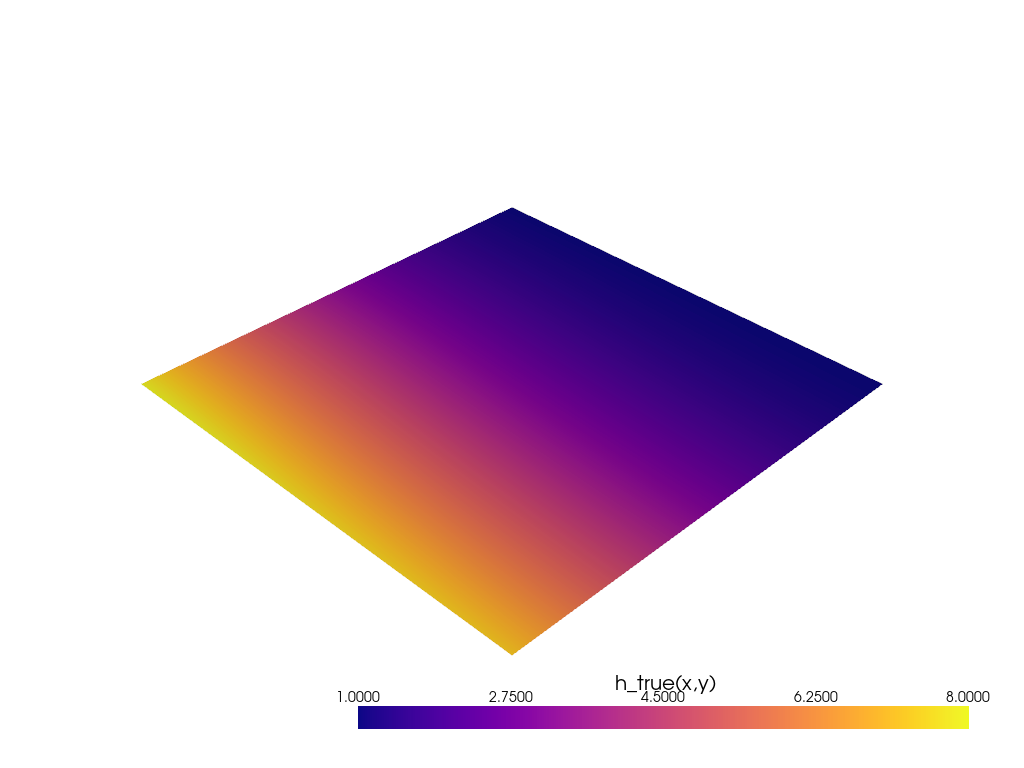

In [4]:
from plotting_utils import plot_scalar_mesh
htrue_grid=plot_scalar_mesh(blackbox_solver.V.mesh,htrue,'h_true(x,y)',cmap='plasma',user_scalar_bar={"fmt": "%.4f"})

Text(0.5, 1.0, 'h_true(x,y)')

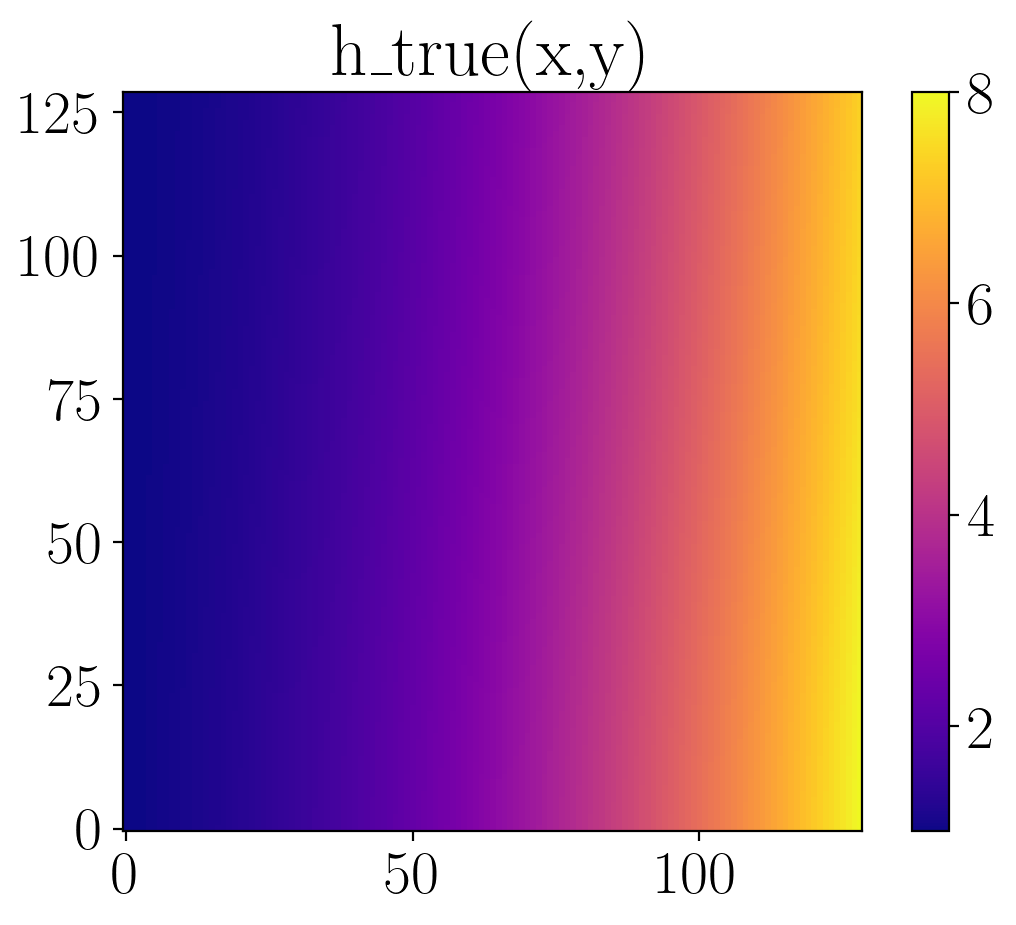

In [5]:
def assemble_RegularGrid_from_UnstructuredGrid(points,point_data):
    pts  = points[:, :2]  # (N, 2) -> x,y
    vals = point_data  # length N

    # Build unique, sorted axes (rounded to kill tiny FP jitter)
    xs = np.unique(np.round(pts[:, 0], 12))
    ys = np.unique(np.round(pts[:, 1], 12))
    nx, ny = len(xs), len(ys)
    assert nx * ny == len(vals), "Grid dims don’t match number of points"

    # Sort by y first (primary), then x (secondary), so rows=Y, cols=X
    order = np.lexsort((pts[:, 0], pts[:, 1]))
    reg_grid = vals[order].reshape(nx, ny)
    return reg_grid

htrue_reg_grid=assemble_RegularGrid_from_UnstructuredGrid(htrue_grid.points,htrue_grid.point_data['h_true(x,y)'])
plt.imshow(
    htrue_reg_grid,
    origin='lower',
    cmap='plasma')
plt.colorbar(); plt.title('h_true(x,y)')

In [6]:
hsols_reg_grid=[assemble_RegularGrid_from_UnstructuredGrid(
    htrue_grid.points,hsols_array[i,:]) for i in range(hsols_array.shape[0])]

Text(0.5, 1.0, 'h_sol(x,y)')

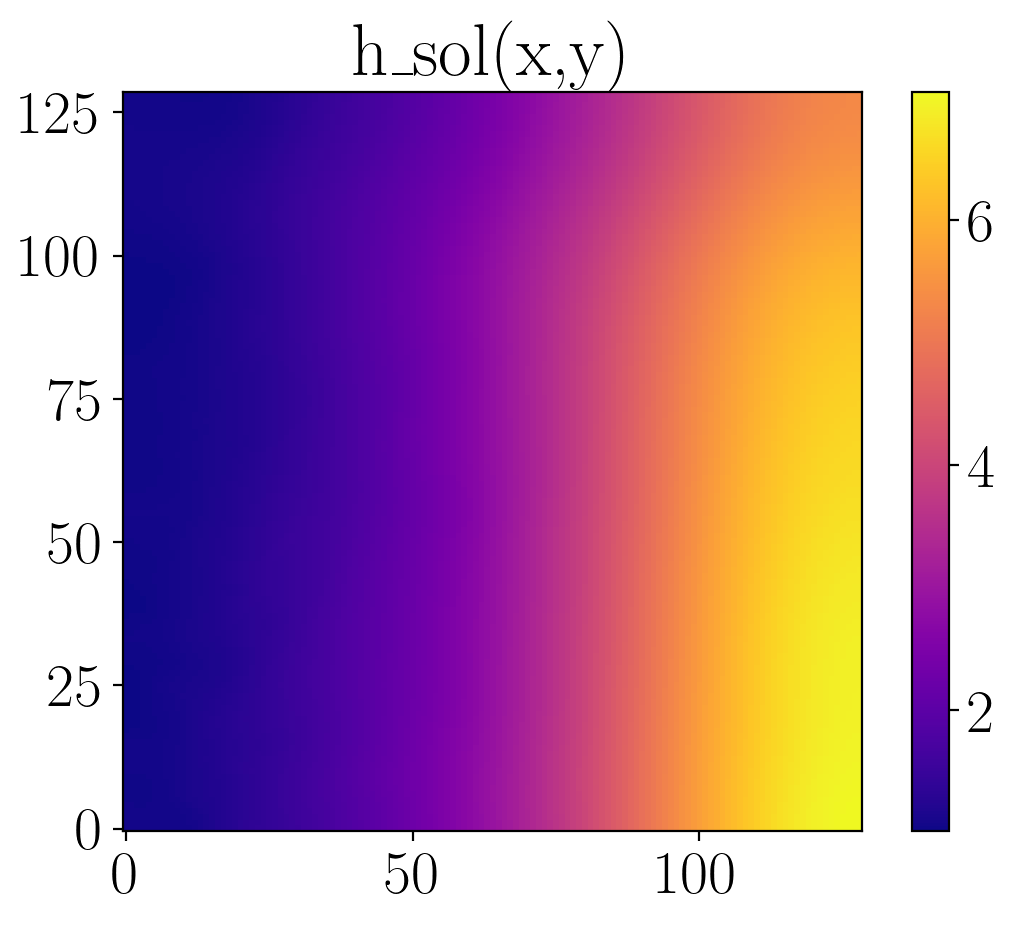

In [7]:
plt.imshow(
    hsols_reg_grid[-1],
    origin='lower',
    cmap='plasma')
plt.colorbar(); plt.title('h_sol(x,y)')

In [8]:
def construct_fourier_grid(nx=129,ny=129,dx=1.0,dy=1.0,nbins=30,log_interval=False):
    kx = np.fft.fftfreq(nx,d=dx)
    ky = np.fft.rfftfreq(ny,d=dy)
    KX, KY = np.meshgrid(kx,ky,indexing='ij')
    kgrid = np.sqrt(KX**2+KY**2)
    if log_interval:
        kedges = np.geomspace(kgrid[kgrid>0].min(), kgrid.max(), nbins+1)
    else:
        kedges = np.linspace(kgrid[kgrid>0].min(), kgrid.max(), nbins+1)
    nks, kedges = np.histogram(kgrid, bins=kedges, range=[kedges.min(), kedges.max()])
    return kgrid, nks, kedges

def compute_h_power_spectrum(grid1,grid2=None,nx=129,ny=129,dx=1.0,dy=1.0,nbins=30):
    grid1_fft=np.fft.rfft2(grid1)
    if grid2 is None:
        grid2_fft=grid1_fft
    else:
        grid2_fft=np.fft.rfft2(grid2)
    kgrid, nks, kedges = construct_fourier_grid(nx=nx,ny=ny,dx=dx,dy=dy,nbins=nbins)
    weights = (grid1_fft*grid2_fft.conj()).real
    Pk, kedges  = np.histogram(kgrid, weights=weights, bins=kedges, range=[kedges.min(), kedges.max()])
    kcenters = 0.5*(kedges[:-1]+kedges[1:])
    return kcenters, Pk/nks

k,Pk_htrue=compute_h_power_spectrum(htrue_reg_grid)
Pk_hsols=[]
Pk_htrue_hsols=[]
rk=[]
for i in range(len(hsols_reg_grid)):
    kcenters,Pk_hsol=compute_h_power_spectrum(hsols_reg_grid[i])
    kcenters,Pk_htrue_hsol=compute_h_power_spectrum(htrue_reg_grid,grid2=hsols_reg_grid[i])
    Pk_hsols.append(Pk_hsol)
    Pk_htrue_hsols.append(Pk_htrue_hsol)
    rk.append(Pk_htrue_hsol/(np.sqrt(Pk_htrue*Pk_hsol)))
Pk_hsols=np.array(Pk_hsols)
Pk_htrue_hsols=np.array(Pk_htrue_hsol)
Tk=np.sqrt(Pk_hsols/Pk_htrue)
rk=np.array(rk)
print(Tk.shape)
print(rk.shape)

(5, 30)
(5, 30)


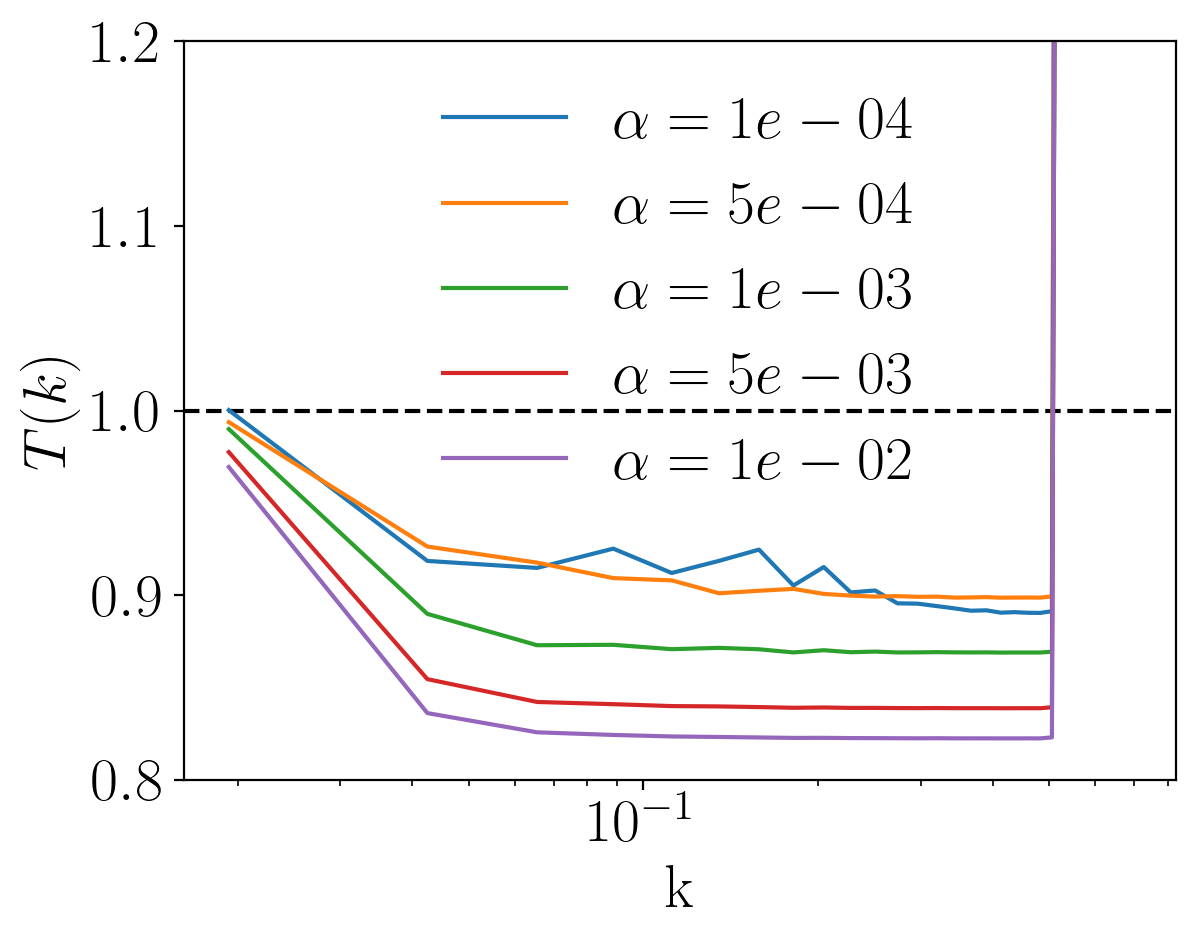

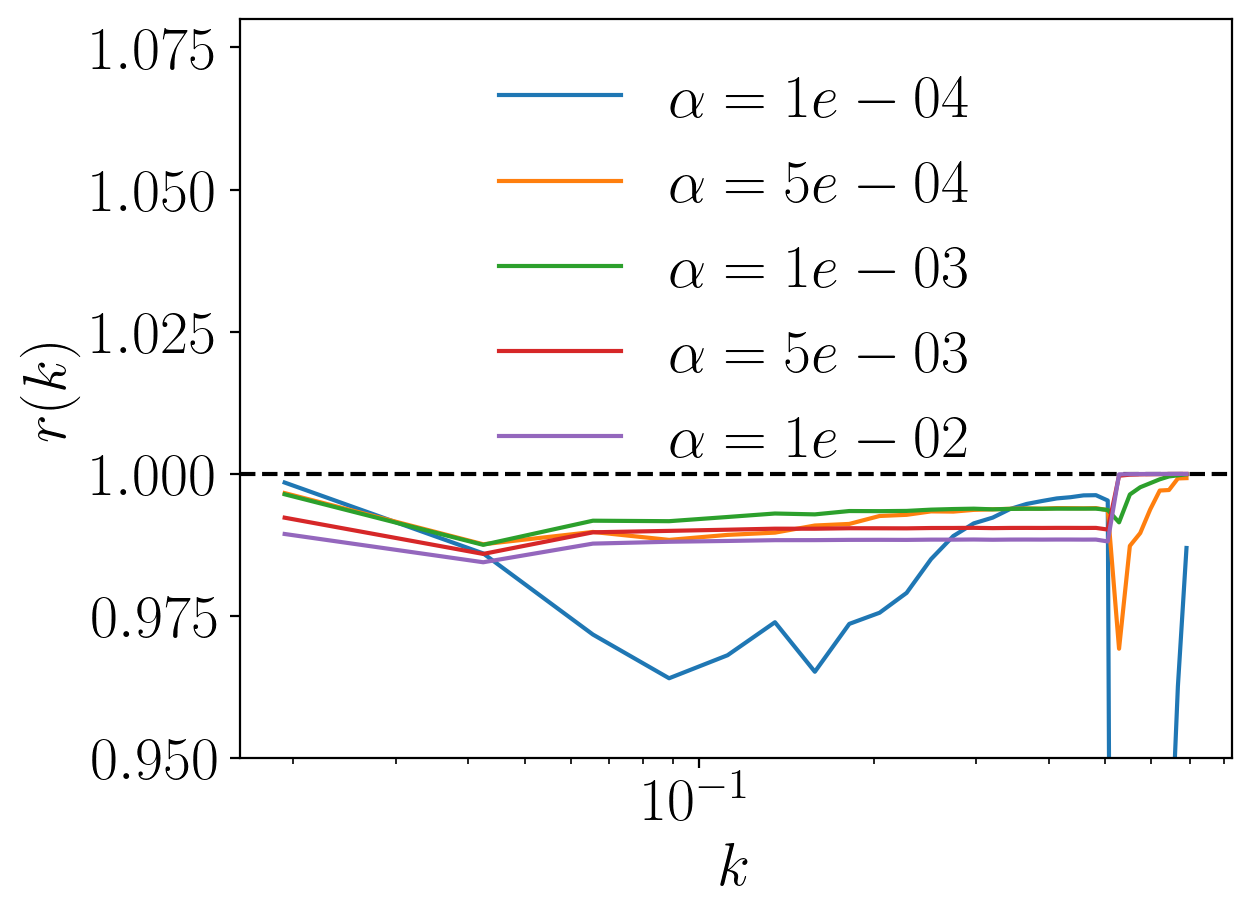

In [9]:
colors = plt.get_cmap('tab10').colors[:len(alphas_array)]

# Plot Tk vs k on semilogx
fig,ax=plt.subplots()
for i, alpha in enumerate(alphas_array):
    ax.semilogx(k, Tk[i], color=colors[i],
                 label = fr'$\alpha={alpha:.0e}$')
ax.set_xlabel('k')
ax.set_ylabel('$T(k)$')
ax.set_ylim(0.8,1.2)
ax.legend(frameon=False)
ax.axhline(y=1.,ls='--',c='black',zorder=0)
#ax.grid(True, which='major')

# Plot rk vs k on semilogx
fig,ax=plt.subplots()
for i, alpha in enumerate(alphas_array):
    ax.semilogx(k, rk[i], color=colors[i],
                 label = fr'$\alpha={alpha:.0e}$')
ax.set_xlabel('$k$')
ax.set_ylabel('$r(k)$')
ax.axhline(y=1.,ls='--',c='black',zorder=0)
ax.set_ylim(0.95,1.08)
ax.legend(frameon=False)
#ax.grid(True, which='major')

(5, 129, 129)


Text(0, 0.5, 'PDF')

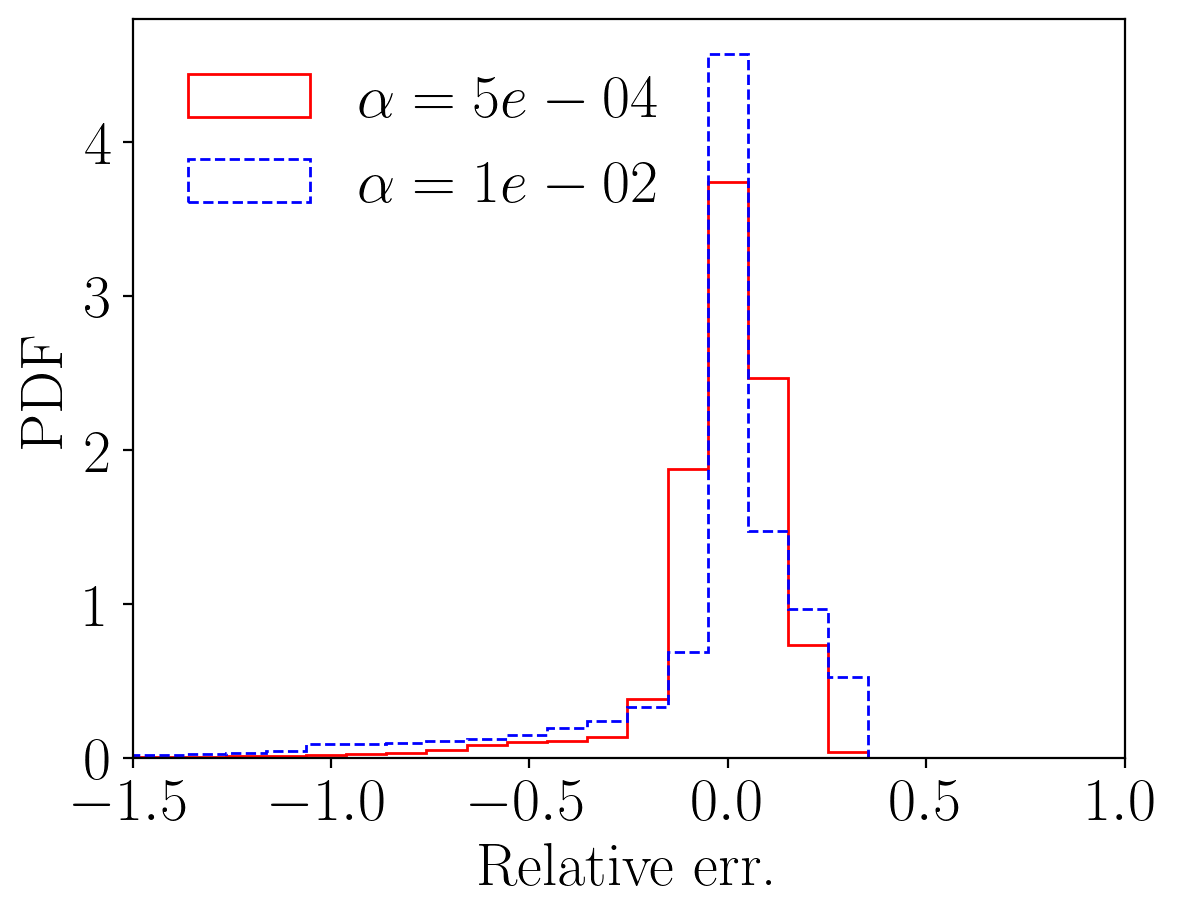

In [12]:
hdiff_hists=hsols_reg_grid-htrue_reg_grid
print(hdiff_hists.shape)

bins=np.linspace(-4.,4.,80)
fig,ax=plt.subplots()
ax.hist(hdiff_hists[1,...].flatten(),bins=bins,density=True,histtype='step',color='r',label = fr'$\alpha={alphas_array[1]:.0e}$')
ax.hist(hdiff_hists[-1,...].flatten(),bins=bins,density=True,histtype='step',ls='--',color='b',label = fr'$\alpha={alphas_array[-1]:.0e}$')
ax.legend(frameon=False)
ax.set_xlim(-1.5,1)
ax.set_xlabel("Relative err.")
ax.set_ylabel("PDF")

In [23]:
hsol_files=['hsol_sigma1e-3_alpha1e-2.npy','hsol_sigma5e-3_alpha5e-4.npy','hsol_sigma1e-2_alpha1e-4.npy']
hsols=[np.load(hsol_file) for hsol_file in hsol_files]
hsols_array=np.array(hsols)
hsols_array.shape

(3, 16641)

In [24]:
hsols_reg_grid=[assemble_RegularGrid_from_UnstructuredGrid(
    htrue_grid.points,hsols_array[i,:]) for i in range(hsols_array.shape[0])]

In [25]:
hdiffs_array=(hsols_reg_grid-htrue_reg_grid)/htrue_reg_grid
hdiffs_array.shape

(3, 129, 129)

(3,)


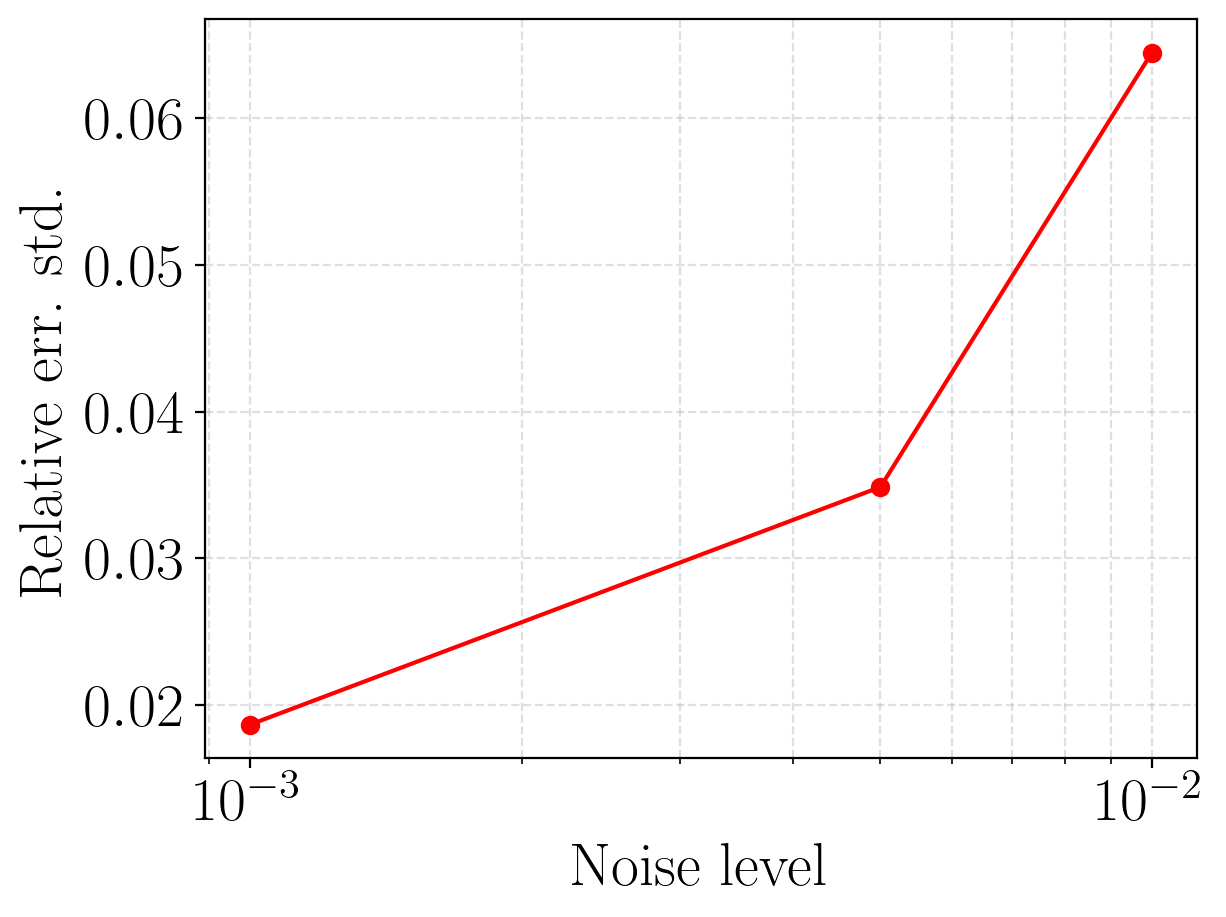

In [28]:
err_std = hdiffs_array.std(axis=(1,2))
print(err_std.shape)

sigmas_array=np.array([1e-3,5e-3,1e-2])
fig, ax = plt.subplots()
ax.semilogx(sigmas_array, err_std, marker='o', color='red')
#ax.semilogx(sigmas_array, y1, marker='o', color='blue', label=fr'$\alpha={alphas[1]}$')

ax.set_xlabel('Noise level')
ax.set_ylabel('Relative err. std.')
#ax.legend(frameon=False)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()